# BAN6800 — BA-10: Threshold Tuning and Cost-Sensitive Evaluation

**Selected classifier:** Random Forest (provisional leader from BA-09)

## Purpose
Determine whether a classification threshold other than 0.50 improves the business-cost trade-off between false positives and false negatives.

### UCI APS cost structure
- False positive cost (Cost_1): **10**
- False negative cost (Cost_2): **500**
- Total Cost = `10 × FP + 500 × FN`

### Experimental controls
- Official UCI test set is **not used** for threshold selection or evaluation.
- The 60,000-row training set is split into 60% model-fit, 20% threshold-tuning, and 20% internal-evaluation partitions.
- All partitions are stratified.
- The Random Forest configuration is carried forward unchanged from BA-09.
- Threshold is selected on the tuning partition only.
- The selected threshold is evaluated on a separate internal holdout.


In [1]:
import os
import json
import warnings
from io import BytesIO

import requests
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
FALSE_POSITIVE_COST = 10
FALSE_NEGATIVE_COST = 500

RF_CONFIG = {
    "n_estimators": 150,
    "class_weight": "balanced_subsample",
    "min_samples_leaf": 2,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

print("BA-10 libraries loaded successfully.")


BA-10 libraries loaded successfully.


In [2]:
# Load the final BA-07 feature arrays and target labels

TRAIN_URL = "https://media.githubusercontent.com/media/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/processed/X_train_final.npy"
TEST_URL = "https://media.githubusercontent.com/media/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/processed/X_test_final.npy"
Y_TRAIN_URL = "https://raw.githubusercontent.com/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/processed/y_train.csv"
Y_TEST_URL = "https://raw.githubusercontent.com/dvfekorigha-create/BAN6800-cgsl-predictive-maintenance/main/data/processed/y_test.csv"

def load_npy_from_url(url, label):
    response = requests.get(url, timeout=180)
    response.raise_for_status()
    print(f"{label}: {len(response.content)/1024**2:.1f} MB downloaded")
    return np.load(BytesIO(response.content), allow_pickle=False)

X_train = load_npy_from_url(TRAIN_URL, "X_train_final")
X_test = load_npy_from_url(TEST_URL, "X_test_final")

y_train = pd.read_csv(Y_TRAIN_URL).squeeze("columns")
y_test = pd.read_csv(Y_TEST_URL).squeeze("columns")

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Test labels:", y_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())


X_train_final: 152.9 MB downloaded
X_test_final: 40.8 MB downloaded
Training features: (60000, 334)
Test features: (16000, 334)
Training labels: (60000,)
Test labels: (16000,)

Training class distribution:
class
neg    59000
pos     1000
Name: count, dtype: int64


In [3]:
# Integrity checks

assert X_train.shape == (60000, 334)
assert X_test.shape == (16000, 334)
assert len(y_train) == 60000
assert len(y_test) == 16000
assert np.isfinite(X_train).all()
assert np.isfinite(X_test).all()

print("BA-10 input integrity checks passed.")


BA-10 input integrity checks passed.


## 1. Create model-fit, threshold-tuning, and internal-evaluation partitions

The official test set is kept completely untouched.

The internal split is:
- 60% model fitting
- 20% threshold tuning
- 20% internal evaluation

The threshold is chosen only from the tuning set and then assessed on the separate evaluation set.


In [4]:
X_fit, X_temp, y_fit, y_temp = train_test_split(
    X_train,
    y_train,
    test_size=0.40,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_tune, X_eval, y_tune, y_eval = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print("Model-fit:", X_fit.shape, " | positives:", int((y_fit == "pos").sum()))
print("Threshold-tuning:", X_tune.shape, " | positives:", int((y_tune == "pos").sum()))
print("Internal-evaluation:", X_eval.shape, " | positives:", int((y_eval == "pos").sum()))


Model-fit: (36000, 334)  | positives: 600
Threshold-tuning: (12000, 334)  | positives: 200
Internal-evaluation: (12000, 334)  | positives: 200


In [5]:
# Fit the BA-09 Random Forest configuration on the model-fit partition

rf = RandomForestClassifier(**RF_CONFIG)
rf.fit(X_fit, y_fit)

print("Random Forest fitted successfully.")
print("Number of trees:", RF_CONFIG["n_estimators"])


Random Forest fitted successfully.
Number of trees: 150


In [6]:
# Generate positive-class probabilities

classes = list(rf.classes_)
pos_index = classes.index("pos")

tune_prob = rf.predict_proba(X_tune)[:, pos_index]
eval_prob = rf.predict_proba(X_eval)[:, pos_index]

print("Tuning probabilities:", tune_prob.shape)
print("Evaluation probabilities:", eval_prob.shape)


Tuning probabilities: (12000,)
Evaluation probabilities: (12000,)


## 2. Define the cost-sensitive evaluation function

The UCI APS challenge assigns a much higher cost to false negatives than false positives. Therefore, the selected threshold will minimize weighted classification cost rather than maximize F1 alone.


In [7]:
def evaluate_threshold(y_true, probabilities, threshold):
    y_pred = np.where(probabilities >= threshold, "pos", "neg")
    cm = confusion_matrix(y_true, y_pred, labels=["neg", "pos"])
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_true, y_pred, pos_label="pos", zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label="pos", zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label="pos", zero_division=0)
    roc_auc = roc_auc_score((y_true == "pos").astype(int), probabilities)

    total_cost = (
        FALSE_POSITIVE_COST * fp
        + FALSE_NEGATIVE_COST * fn
    )

    return {
        "Threshold": float(threshold),
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": roc_auc,
        "True_Negatives": int(tn),
        "False_Positives": int(fp),
        "False_Negatives": int(fn),
        "True_Positives": int(tp),
        "Total_Cost": int(total_cost),
        "Cost_per_Observation": total_cost / len(y_true),
    }


In [8]:
# Baseline threshold on tuning data

baseline_tune = evaluate_threshold(
    y_tune,
    tune_prob,
    0.50
)

print("Baseline threshold = 0.50")
display(pd.DataFrame([baseline_tune]))


Baseline threshold = 0.50


,Threshold,Precision,Recall,F1_Score,ROC_AUC,True_Negatives,False_Positives,False_Negatives,True_Positives,Total_Cost,Cost_per_Observation
0,0.5,0.844595,0.625,0.718391,0.985521,11777,23,75,125,37730,3.144167


In [9]:
# Search thresholds from 0.01 to 0.99

threshold_grid = np.round(np.arange(0.01, 1.00, 0.01), 2)

threshold_results = pd.DataFrame([
    evaluate_threshold(y_tune, tune_prob, threshold)
    for threshold in threshold_grid
])

best_tune = threshold_results.loc[
    threshold_results["Total_Cost"].idxmin()
]

selected_threshold = float(best_tune["Threshold"])

print("Selected threshold:", selected_threshold)
print("Minimum tuning-set cost:", int(best_tune["Total_Cost"]))

display(threshold_results.sort_values("Total_Cost").head(10))


Selected threshold: 0.1
Minimum tuning-set cost: 8030


,Threshold,Precision,Recall,F1_Score,ROC_AUC,True_Negatives,False_Positives,False_Negatives,True_Positives,Total_Cost,Cost_per_Observation
9,0.10,0.351103,0.955,0.513441,0.985521,11447,353,9,191,8030,0.669167
8,0.09,0.335088,0.955,0.496104,0.985521,11421,379,9,191,8290,0.690833
10,0.11,0.357143,0.950,0.519126,0.985521,11458,342,10,190,8420,0.701667
6,0.07,0.302362,0.960,0.459880,0.985521,11357,443,8,192,8430,0.702500
7,0.08,0.325939,0.955,0.486005,0.985521,11405,395,9,191,8450,0.704167
5,0.06,0.294931,0.960,0.451234,0.985521,11341,459,8,192,8590,0.715833
14,0.15,0.441038,0.935,0.599359,0.985521,11563,237,13,187,8870,0.739167
13,0.14,0.435897,0.935,0.594595,0.985521,11558,242,13,187,8920,0.743333
12,0.13,0.390041,0.940,0.551320,0.985521,11506,294,12,188,8940,0.745000
11,0.12,0.376754,0.940,0.537911,0.985521,11489,311,12,188,9110,0.759167


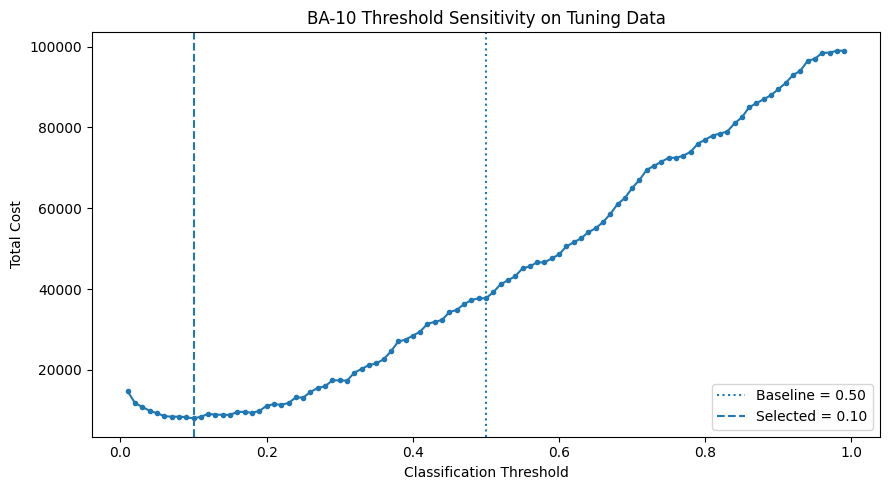

Saved: BA-10_threshold_cost_curve.png


In [10]:
# Plot threshold sensitivity

plt.figure(figsize=(9, 5))
plt.plot(
    threshold_results["Threshold"],
    threshold_results["Total_Cost"],
    marker="o",
    markersize=3,
)
plt.axvline(
    0.50,
    linestyle=":",
    label="Baseline = 0.50",
)
plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected = {selected_threshold:.2f}",
)
plt.xlabel("Classification Threshold")
plt.ylabel("Total Cost")
plt.title("BA-10 Threshold Sensitivity on Tuning Data")
plt.legend()
plt.tight_layout()
plt.savefig("BA-10_threshold_cost_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: BA-10_threshold_cost_curve.png")


## 3. Evaluate the locked threshold on the internal evaluation set

The selected threshold is now locked. Performance and cost are measured on the separate internal-evaluation partition.

This provides an independent check within the training-data pool before any future use of the official UCI test set.


In [11]:
eval_baseline = evaluate_threshold(
    y_eval,
    eval_prob,
    0.50
)

eval_selected = evaluate_threshold(
    y_eval,
    eval_prob,
    selected_threshold
)

comparison = pd.DataFrame([
    {"Setting": "Baseline 0.50", **eval_baseline},
    {"Setting": f"Selected {selected_threshold:.2f}", **eval_selected},
])

baseline_cost = eval_baseline["Total_Cost"]
comparison["Cost_Reduction_vs_0.50"] = baseline_cost - comparison["Total_Cost"]
comparison["Cost_Reduction_Percent_vs_0.50"] = (
    comparison["Cost_Reduction_vs_0.50"] / baseline_cost * 100
    if baseline_cost > 0 else 0
)

display(comparison)


,Setting,Threshold,Precision,Recall,F1_Score,ROC_AUC,True_Negatives,False_Positives,False_Negatives,True_Positives,Total_Cost,Cost_per_Observation,Cost_Reduction_vs_0.50,Cost_Reduction_Percent_vs_0.50
0,Baseline 0.50,0.5,0.828025,0.650,0.728291,0.98111,11773,27,70,130,35270,2.939167,0,0.000000
1,Selected 0.10,0.1,0.362069,0.945,0.523546,0.98111,11467,333,11,189,8830,0.735833,26440,74.964559


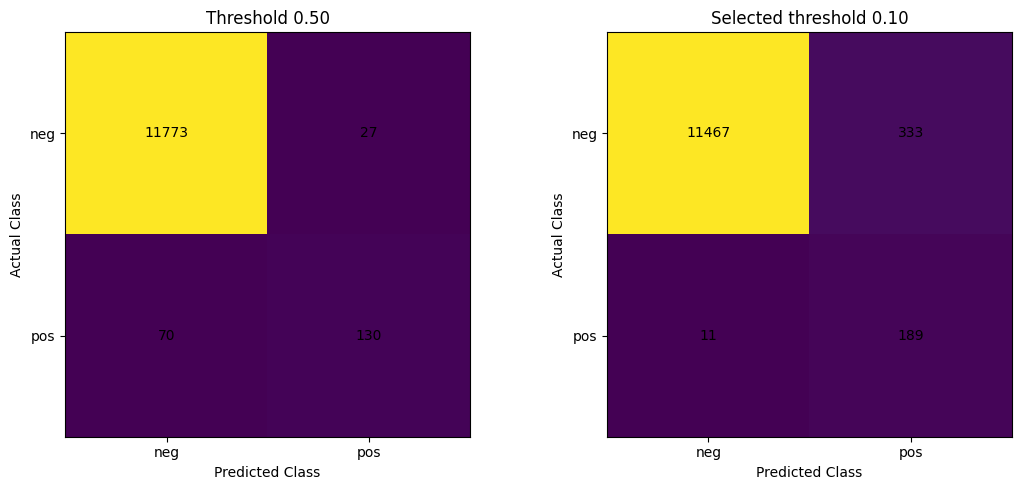

Saved: BA-10_threshold_confusion_matrices.png


In [12]:
# Confusion matrices: baseline versus selected threshold

baseline_cm = confusion_matrix(
    y_eval,
    np.where(eval_prob >= 0.50, "pos", "neg"),
    labels=["neg", "pos"],
)

selected_cm = confusion_matrix(
    y_eval,
    np.where(eval_prob >= selected_threshold, "pos", "neg"),
    labels=["neg", "pos"],
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, cm, title in [
    (axes[0], baseline_cm, "Threshold 0.50"),
    (axes[1], selected_cm, f"Selected threshold {selected_threshold:.2f}"),
]:
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")
    ax.set_xticks([0, 1], ["neg", "pos"])
    ax.set_yticks([0, 1], ["neg", "pos"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.savefig("BA-10_threshold_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved: BA-10_threshold_confusion_matrices.png")


## 4. BA-10 interpretation

The cost-minimizing threshold is selected using the UCI cost asymmetry. A lower threshold can reduce expensive false negatives while increasing false positives.

The selected threshold should therefore be judged by:
- total weighted cost,
- recall,
- precision,
- F1-score,
- and the operational trade-off between missed failures and unnecessary inspections.

This remains a human-supervised decision-support analysis rather than an autonomous maintenance control.


In [13]:
# Save all BA-10 evidence

threshold_results.to_csv(
    "BA-10_threshold_sensitivity.csv",
    index=False
)

comparison.to_csv(
    "BA-10_threshold_evaluation_comparison.csv",
    index=False
)

pd.DataFrame([{
    "False_Positive_Cost": FALSE_POSITIVE_COST,
    "False_Negative_Cost": FALSE_NEGATIVE_COST,
    "Selected_Threshold": selected_threshold,
    "Tuning_Minimum_Cost": int(best_tune["Total_Cost"]),
}]).to_csv(
    "BA-10_cost_configuration.csv",
    index=False
)

print("Saved:")
print("- BA-10_threshold_sensitivity.csv")
print("- BA-10_threshold_evaluation_comparison.csv")
print("- BA-10_cost_configuration.csv")


Saved:
- BA-10_threshold_sensitivity.csv
- BA-10_threshold_evaluation_comparison.csv
- BA-10_cost_configuration.csv


In [14]:
# Fit the selected Random Forest configuration on all training data
# after the threshold-selection step is complete.

rf_final = RandomForestClassifier(**RF_CONFIG)
rf_final.fit(X_train, y_train)

joblib.dump(
    rf_final,
    "random_forest_selected_baseline.joblib"
)

with open("BA-10_selected_threshold.txt", "w", encoding="utf-8") as f:
    f.write(str(selected_threshold))

print("Saved final model: random_forest_selected_baseline.joblib")
print("Saved selected threshold:", selected_threshold)


Saved final model: random_forest_selected_baseline.joblib
Saved selected threshold: 0.1


In [15]:
# Save reproducibility configuration

run_config = {
    "ticket": "BA-10",
    "selected_model": "Random Forest",
    "random_state": RANDOM_STATE,
    "n_estimators": RF_CONFIG["n_estimators"],
    "class_weight": RF_CONFIG["class_weight"],
    "min_samples_leaf": RF_CONFIG["min_samples_leaf"],
    "false_positive_cost": FALSE_POSITIVE_COST,
    "false_negative_cost": FALSE_NEGATIVE_COST,
    "fit_fraction": 0.60,
    "threshold_tuning_fraction": 0.20,
    "internal_evaluation_fraction": 0.20,
    "threshold_grid": "0.01 to 0.99 by 0.01",
    "official_test_set_used": False,
    "selected_threshold": selected_threshold,
}

with open("BA-10_run_config.json", "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2)

print("Saved: BA-10_run_config.json")


Saved: BA-10_run_config.json


In [16]:
# Generate an automatic BA-10 report populated from actual results

base = comparison.iloc[0]
selected = comparison.iloc[1]

report = (
    "# BA-10 Threshold Tuning and Cost-Sensitive Evaluation\n\n"
    "## Selected classifier\n"
    "Random Forest, carried forward from BA-09.\n\n"
    "## Cost structure\n"
    f"- False-positive cost: {FALSE_POSITIVE_COST}\n"
    f"- False-negative cost: {FALSE_NEGATIVE_COST}\n"
    "- Total cost = 10 × FP + 500 × FN.\n\n"
    "## Experimental design\n"
    "- 60% model-fit partition.\n"
    "- 20% threshold-tuning partition.\n"
    "- 20% internal-evaluation partition.\n"
    "- All partitions stratified.\n"
    "- Official UCI test set not used.\n"
    "- Threshold grid: 0.01–0.99 in 0.01 increments.\n\n"
    "## Results\n"
    f"- Baseline threshold: 0.50\n"
    f"- Selected threshold: {selected_threshold:.2f}\n"
    f"- Baseline evaluation cost: {int(base['Total_Cost'])}\n"
    f"- Selected-threshold evaluation cost: {int(selected['Total_Cost'])}\n"
    f"- Cost reduction: {int(selected['Cost_Reduction_vs_0.50'])}\n"
    f"- Cost reduction (%): {selected['Cost_Reduction_Percent_vs_0.50']:.2f}%\n"
    f"- Baseline precision: {base['Precision']:.4f}\n"
    f"- Baseline recall: {base['Recall']:.4f}\n"
    f"- Baseline F1-score: {base['F1_Score']:.4f}\n"
    f"- Selected-threshold precision: {selected['Precision']:.4f}\n"
    f"- Selected-threshold recall: {selected['Recall']:.4f}\n"
    f"- Selected-threshold F1-score: {selected['F1_Score']:.4f}\n"
    f"- ROC-AUC: {selected['ROC_AUC']:.4f}\n\n"
    "## Interpretation\n"
    "The selected threshold minimizes the UCI-weighted classification cost on the threshold-tuning partition and is then assessed on a separate internal-evaluation partition. "
    "Because false negatives carry a substantially higher cost than false positives, the cost-minimizing threshold may differ from 0.50. "
    "The selected threshold is a decision-support parameter and does not authorize autonomous maintenance action.\n\n"
    "## Scope limitation\n"
    "The UCI APS dataset is a public proxy for CGSL. These results demonstrate the analytical method and should not be interpreted as direct evidence of CGSL vessel or equipment performance."
)

with open("BA-10_cost_sensitive_report.md", "w", encoding="utf-8") as f:
    f.write(report)

print("Saved: BA-10_cost_sensitive_report.md")


Saved: BA-10_cost_sensitive_report.md


In [17]:
# Final BA-10 artifact inventory

artifact_files = [
    "BA-10_threshold_sensitivity.csv",
    "BA-10_threshold_evaluation_comparison.csv",
    "BA-10_cost_configuration.csv",
    "BA-10_threshold_cost_curve.png",
    "BA-10_threshold_confusion_matrices.png",
    "BA-10_run_config.json",
    "BA-10_selected_threshold.txt",
    "BA-10_cost_sensitive_report.md",
    "random_forest_selected_baseline.joblib",
]

for name in artifact_files:
    print(f"{name}: {'READY' if os.path.exists(name) else 'MISSING'}")


BA-10_threshold_sensitivity.csv: READY
BA-10_threshold_evaluation_comparison.csv: READY
BA-10_cost_configuration.csv: READY
BA-10_threshold_cost_curve.png: READY
BA-10_threshold_confusion_matrices.png: READY
BA-10_run_config.json: READY
BA-10_selected_threshold.txt: READY
BA-10_cost_sensitive_report.md: READY
random_forest_selected_baseline.joblib: READY


In [18]:
# Create a single downloadable BA-10 artifact bundle

from google.colab import files
import zipfile

artifact_files = [
    "BA-10_threshold_sensitivity.csv",
    "BA-10_threshold_evaluation_comparison.csv",
    "BA-10_cost_configuration.csv",
    "BA-10_threshold_cost_curve.png",
    "BA-10_threshold_confusion_matrices.png",
    "BA-10_run_config.json",
    "BA-10_selected_threshold.txt",
    "BA-10_cost_sensitive_report.md",
    "random_forest_selected_baseline.joblib",
]

missing = [name for name in artifact_files if not os.path.exists(name)]
if missing:
    raise FileNotFoundError(f"Missing artifacts: {missing}")

zip_name = "BA-10_artifacts.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for name in artifact_files:
        z.write(name)

print(f"Created {zip_name}")
files.download(zip_name)


Created BA-10_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>